In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.data.data_models.synthetic_image import SyntheticImage
from DNAnet.data.data_models.dna_models import Panel

from DNAnet.data.parsing import get_peak_data
from DNAnet.evaluation.visualizations import plot_profile
from DNAnet.data.data_models.dna_models import Annotation
from DNAnet.evaluation.visualizations import plot_profile_markers


import matplotlib.pyplot as plt
import numpy as np

# Create HID Image

In [3]:
dataset_files_dir = "resources/data/synthetic/fixed_ratios_base_template_500_5000_no_preprocess/epgs/epg_configID1_sample_0001_N2_250_250_bb_rep1_deg1.npy"
gf_panel_path = "resources/data/synthetic/SGPanel_Globalfiler_Panel.xml"
reference_genotype_path = "resources/data/synthetic/fixed_ratios_base_template_500_5000_no_preprocess/reference_genotypes"
epg_to_genotypes_mapping_path = "resources/data/synthetic/fixed_ratios_base_template_500_5000_no_preprocess/alleles_to_genotypes_mapping.csv"

image = SyntheticImage(
    path=dataset_files_dir,
    panel=Panel(gf_panel_path),
    reference_genotype_path=reference_genotype_path,
    epg_to_genotypes_mapping_path=epg_to_genotypes_mapping_path,
    size_standard="SYNTHETIC_GENESCAN_600_LIZ",
)

print(image.data.shape)
print(image.annotation.image.sum())

(5, 4096, 1)
627


### Visualization

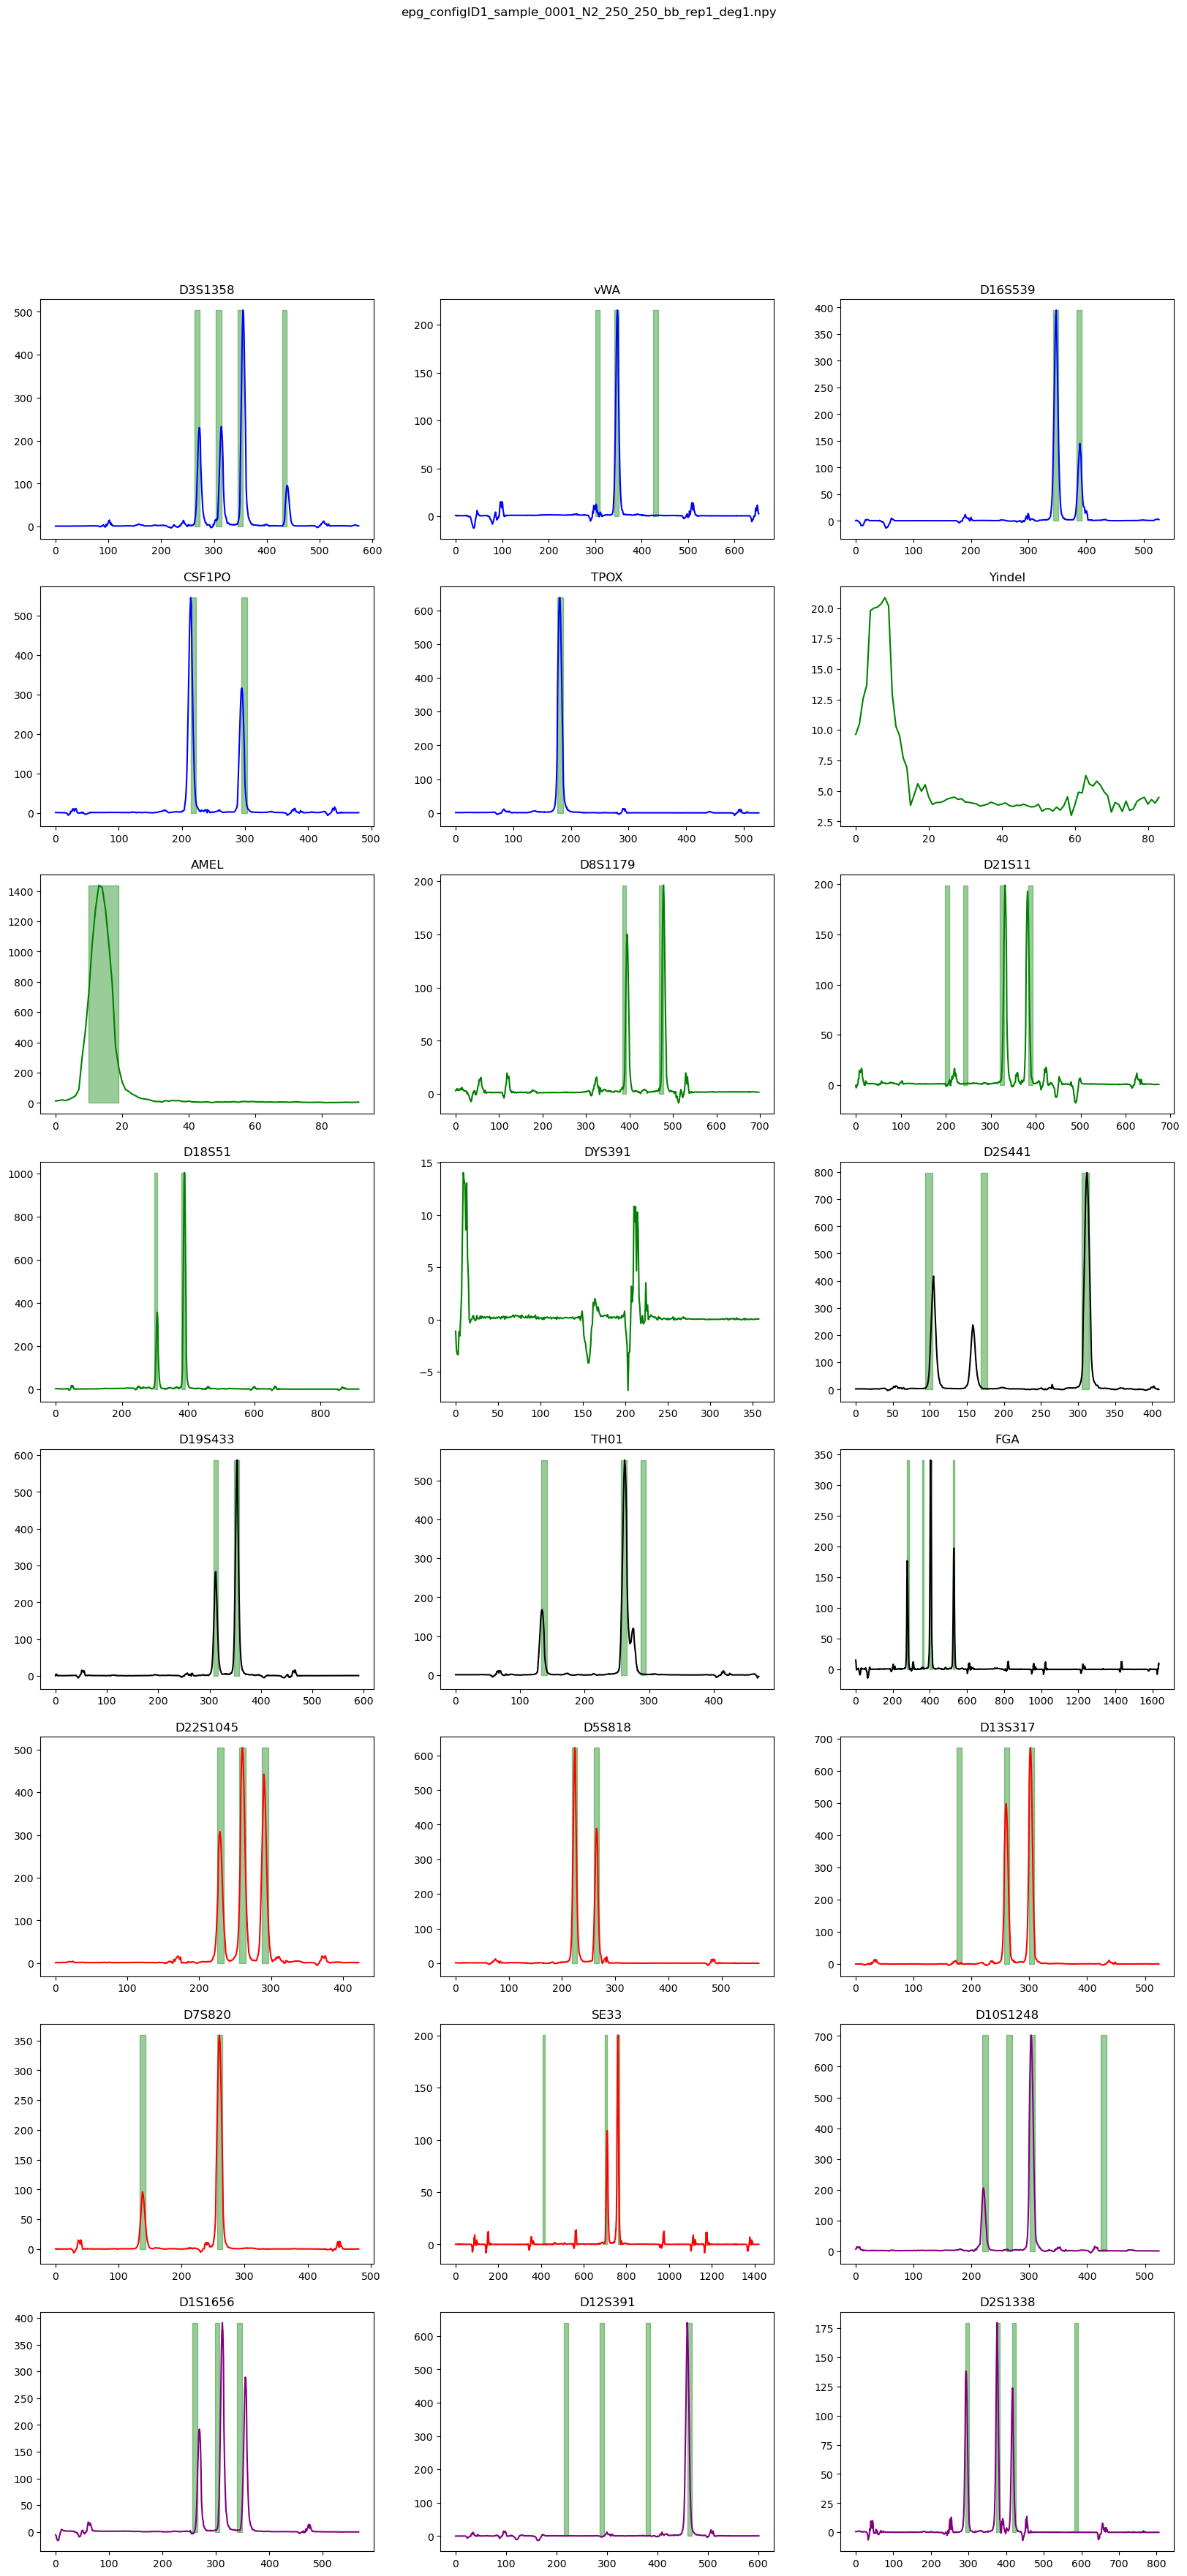

In [4]:
# plot_profile(hid_images=[image])
plot_profile_markers(hid_images=[image])

In [5]:
epg = get_peak_data(image.path) # shape: (6, 4096)

def plot_epg_together(epg):
    plt.figure(figsize=(12, 6))
    dye_labels = ['Blue', 'Green', 'Yellow', 'Red', 'Purple', 'Orange']  # Optional: adjust per your kit

    for i in range(epg.shape[0]):
        plt.plot(epg[i], label=f'Channel {i+1} ({dye_labels[i]})')

    plt.xlabel("Data Points (size bins)")
    plt.ylabel("Fluorescence Intensity")
    plt.title("Electropherogram (EPG) Peak Signals by Dye Channel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_epg_together(epg)
# # plot_epg_together(annotation_image_mock_data)

UnicodeDecodeError: 'utf-8' codec can't decode byte 0x93 in position 0: invalid start byte

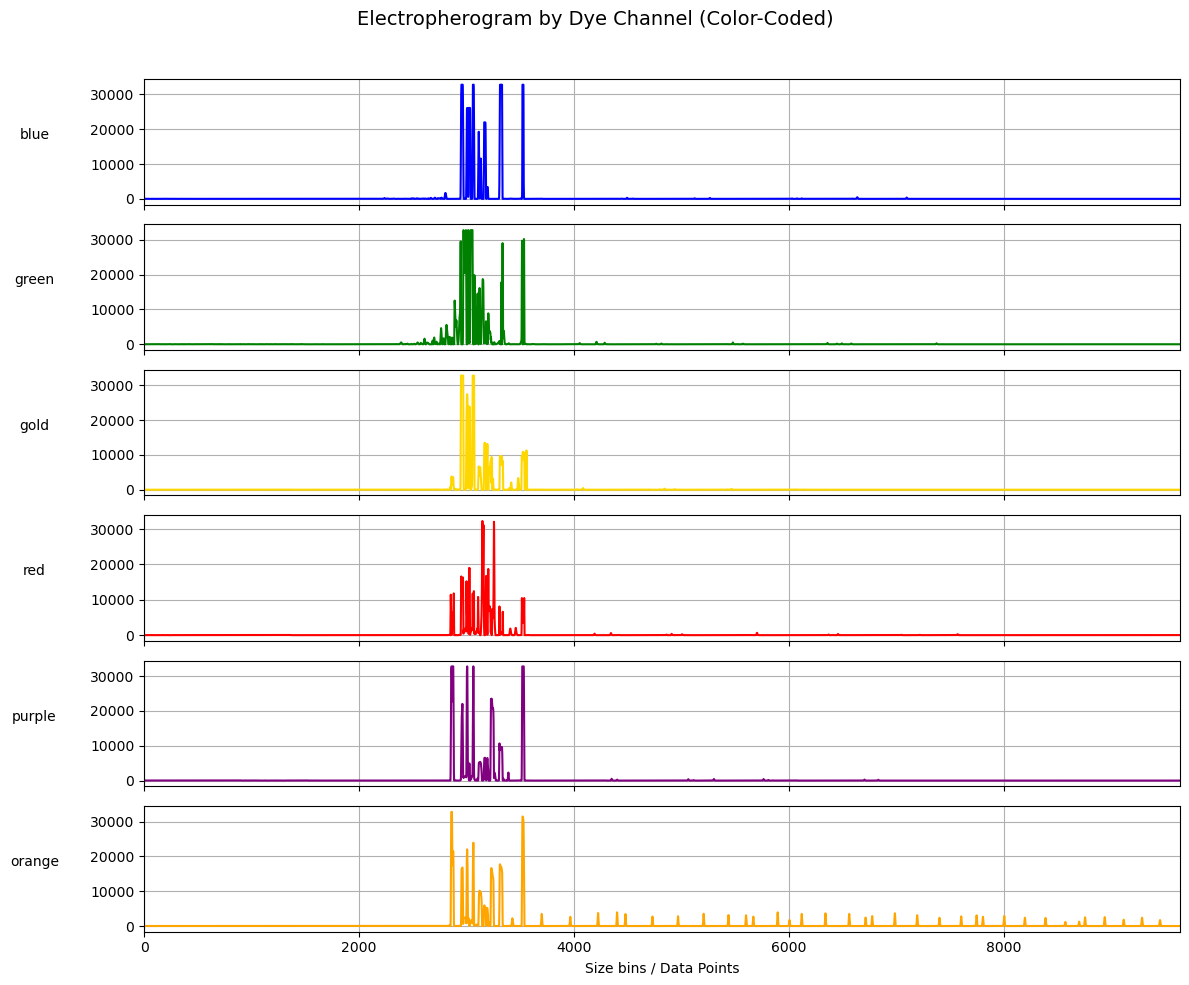

In [ ]:
dye_colors = ['blue', 'green', 'gold', 'red', 'purple', 'orange']

fig, axs = plt.subplots(6, 1, figsize=(12, 10), sharex=True)

for i in range(6):
    axs[i].plot(epg[i], color=dye_colors[i])
    axs[i].set_ylabel(dye_colors[i], rotation=0, labelpad=40, fontsize=10)
    axs[i].grid(True)
    axs[i].set_xlim(0, epg.shape[1])

axs[-1].set_xlabel("Size bins / Data Points")
plt.suptitle("Electropherogram by Dye Channel (Color-Coded)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
